
Dataset:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


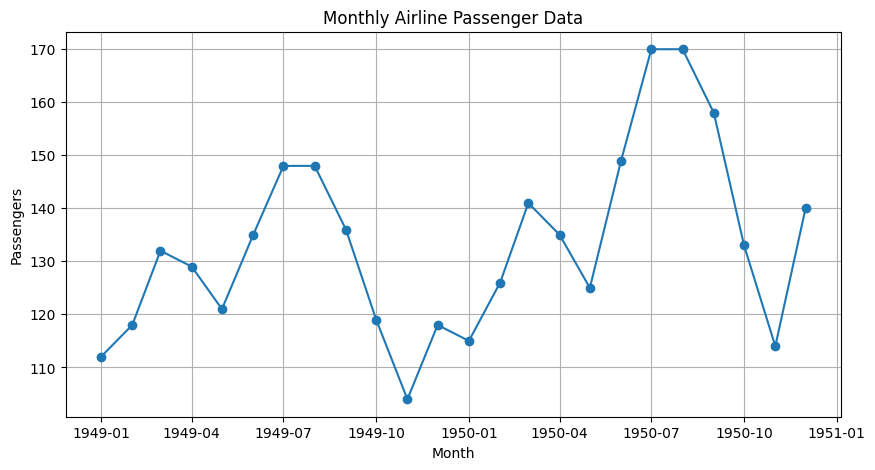


ADF Test on Original Data

ADF Statistic : -3.2170126354951156
p-value : 0.019020800434951846
Data is Stationary


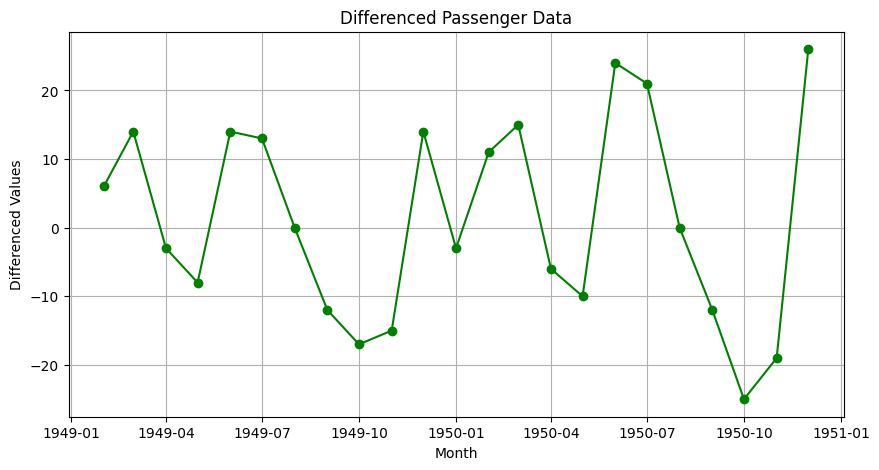


ADF Test After Differencing

ADF Statistic : -2.4286934394013837
p-value : 0.13380110742177737
Data is Non-Stationary


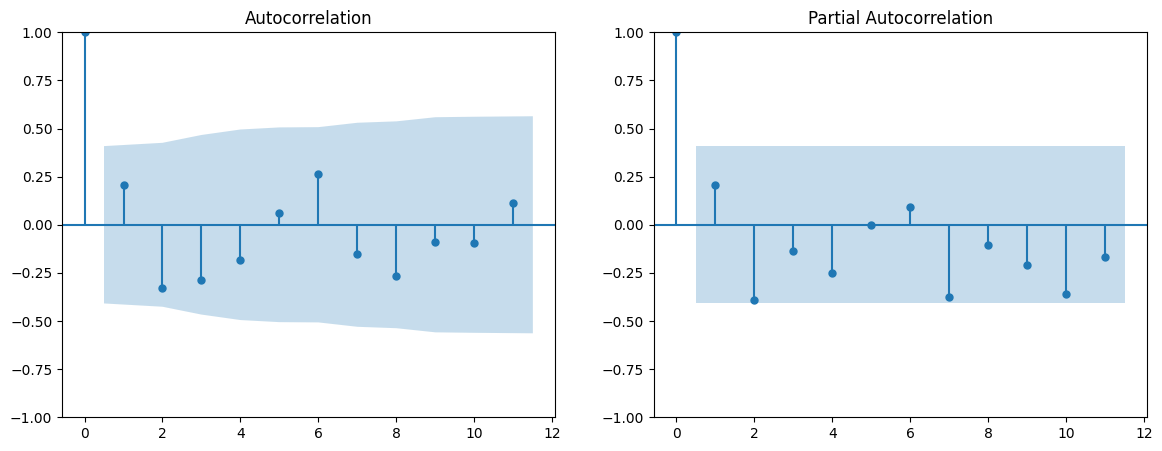


Training Data Size : 19
Testing Data Size : 5


C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



ARIMA Model Summary
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                   19
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -70.237
Date:                Fri, 08 May 2026   AIC                            146.474
Time:                        10:25:01   BIC                            149.146
Sample:                    01-01-1949   HQIC                           146.843
                         - 07-01-1950                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1850      0.773     -0.239      0.811      -1.699       1.329
ma.L1          0.5917      0.635      0.931      0.352      -0.654       1.837
sigma2       141.6340     68.06

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


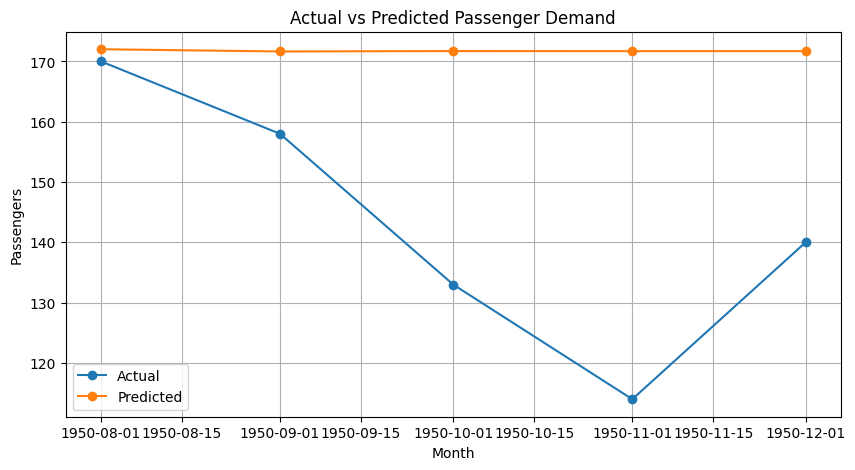


Future Passenger Forecast:
1950-08-01    172.020002
1950-09-01    171.646253
1950-10-01    171.715405
1950-11-01    171.702610
1950-12-01    171.704978
1951-01-01    171.704540
Freq: MS, Name: predicted_mean, dtype: float64


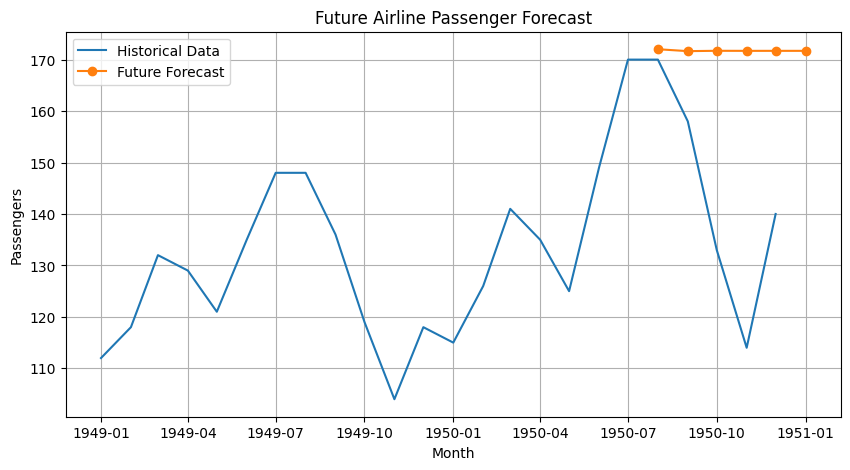

In [1]:
# Airline Passenger Demand Forecasting using ARIMA
# ------------------------------------------------
# Requirements:
# pip install pandas numpy matplotlib statsmodels scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------
# STEP 1 : Load Dataset
# ------------------------------------------------

# Create sample airline passenger dataset
data = {
    "Month": [
        "1949-01","1949-02","1949-03","1949-04","1949-05","1949-06",
        "1949-07","1949-08","1949-09","1949-10","1949-11","1949-12",
        "1950-01","1950-02","1950-03","1950-04","1950-05","1950-06",
        "1950-07","1950-08","1950-09","1950-10","1950-11","1950-12"
    ],
    "Passengers": [
        112,118,132,129,121,135,
        148,148,136,119,104,118,
        115,126,141,135,125,149,
        170,170,158,133,114,140
    ]
}

df = pd.DataFrame(data)

# Convert Month column to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Set Month as index
df.set_index("Month", inplace=True)

print("\nDataset:")
print(df.head())

# ------------------------------------------------
# STEP 2 : Plot Original Data
# ------------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(df["Passengers"], marker='o')
plt.title("Monthly Airline Passenger Data")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

# ------------------------------------------------
# STEP 3 : Check Stationarity using ADF Test
# ------------------------------------------------

def adf_test(series):
    result = adfuller(series)

    print("\nADF Statistic :", result[0])
    print("p-value :", result[1])

    if result[1] <= 0.05:
        print("Data is Stationary")
    else:
        print("Data is Non-Stationary")

print("\nADF Test on Original Data")
adf_test(df["Passengers"])

# ------------------------------------------------
# STEP 4 : Apply Differencing
# ------------------------------------------------

df["Passengers_diff"] = df["Passengers"].diff()

# Remove null values
df_diff = df["Passengers_diff"].dropna()

# Plot differenced data
plt.figure(figsize=(10,5))
plt.plot(df_diff, color='green', marker='o')
plt.title("Differenced Passenger Data")
plt.xlabel("Month")
plt.ylabel("Differenced Values")
plt.grid(True)
plt.show()

print("\nADF Test After Differencing")
adf_test(df_diff)

# ------------------------------------------------
# STEP 5 : Plot ACF and PACF
# ------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(df_diff, ax=axes[0])
plot_pacf(df_diff, ax=axes[1])

plt.show()

# ------------------------------------------------
# STEP 6 : Train-Test Split
# ------------------------------------------------

train_size = int(len(df) * 0.8)

train = df["Passengers"][:train_size]
test = df["Passengers"][train_size:]

print("\nTraining Data Size :", len(train))
print("Testing Data Size :", len(test))

# ------------------------------------------------
# STEP 7 : Build ARIMA Model
# ------------------------------------------------

# ARIMA(p,d,q)
# p = 1
# d = 1 (because differencing applied)
# q = 1

model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

print("\nARIMA Model Summary")
print(model_fit.summary())

# ------------------------------------------------
# STEP 8 : Make Predictions
# ------------------------------------------------

start = len(train)
end = len(train) + len(test) - 1

predictions = model_fit.predict(start=start, end=end, typ='levels')

print("\nPredicted Values:")
print(predictions)

# ------------------------------------------------
# STEP 9 : Evaluation Metrics
# ------------------------------------------------

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

print("\nModel Evaluation")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)

# ------------------------------------------------
# STEP 10 : Plot Actual vs Predicted
# ------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(test.index, test, label="Actual", marker='o')
plt.plot(test.index, predictions, label="Predicted", marker='o')

plt.title("Actual vs Predicted Passenger Demand")
plt.xlabel("Month")
plt.ylabel("Passengers")

plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------
# STEP 11 : Forecast Future Values
# ------------------------------------------------

future_forecast = model_fit.forecast(steps=6)

print("\nFuture Passenger Forecast:")
print(future_forecast)

# Plot future forecast
plt.figure(figsize=(10,5))

plt.plot(df.index, df["Passengers"], label="Historical Data")
plt.plot(future_forecast.index, future_forecast,
         label="Future Forecast", marker='o')

plt.title("Future Airline Passenger Forecast")
plt.xlabel("Month")
plt.ylabel("Passengers")

plt.legend()
plt.grid(True)
plt.show()